In [1]:
%%bash
python ./gfm_run_all.py \
            --adata-path "./data/preprocessed_replogle_k562_small.h5ad" \
            --split-dict-path "./data/adata_replogle_k562_small_split_dict.pkl" \
            --output-dir "./data/gfm/test/" \
            --graph-dir "./data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_go+gwps+ppi_gat.pt" \
            --graph-type "go+pert+ppi" \
            --save-times \

Seed set to 42


Using device: cuda:0

Configuration:
  adata_path                    : ./data/preprocessed_replogle_k562_small.h5ad
  aggregation_method            : sum
  early_stopping_patience       : 4
  eval_freq                     : 50
  graph_dir                     : ./data/
  graph_type                    : go+pert+ppi
  latent_dim                    : 50
  lr                            : 0.0005
  max_epochs                    : 500
  model_name                    : gfm_go+gwps+ppi_gat.pt
  no_fm                         : False
  output_dir                    : ./data/gfm/test/
  pert_adata_path               : None
  pert_encoding                 : gat
  randomize_graph               : False
  save_times                    : True
  skip_metrics                  : False
  skip_model_training           : False
  skip_prediction               : False
  skip_vae_pretrain             : False
  split_df_path                 : None
  split_dict_path               : ./data/adata_replogle_k562_small

100%|█████████�| 1/1 [00:01<00:00,  1.74s/it]��| 1/1 [00:01<00:00,  1.74s/it]


Inference time: 1.75s
Predictions saved to ./data/gfm/test//adata_pred_gfm_go+gwps+ppi_gat.h5ad
Computing metrics...
Detected backed AnnData - using threading backend for parallelization (n_jobs=32)...


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   3 out of   3 | elapsed:    0.5s finished


Results saved to ./data/gfm/test//results_test_gfm_go+gwps+ppi_gat.csv
Timing saved to ./data/gfm/test/timing.json
Done!


In [2]:
import warnings

warnings.filterwarnings('ignore')

from gfm.visualization import (
    get_adata_condition_subset,
    plot_delta_expression_boxplot_model,
    plot_umap_by_model,
)

In [3]:
condition = 'NOL6+ctrl'
adata_paths = {
    "Truth": "./data/preprocessed_replogle_k562_small.h5ad",
    "GFM": "./data/gfm/test/adata_pred_gfm_go+gwps+ppi_gat.h5ad",
}
adata = get_adata_condition_subset(adata_paths, condition=condition)

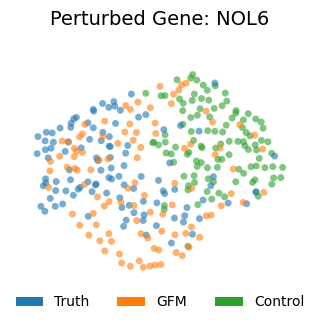

In [4]:
plot_umap_by_model(adata, adata_paths, None, condition=condition, models=['GFM'], figsize=(3, 3), size=100)

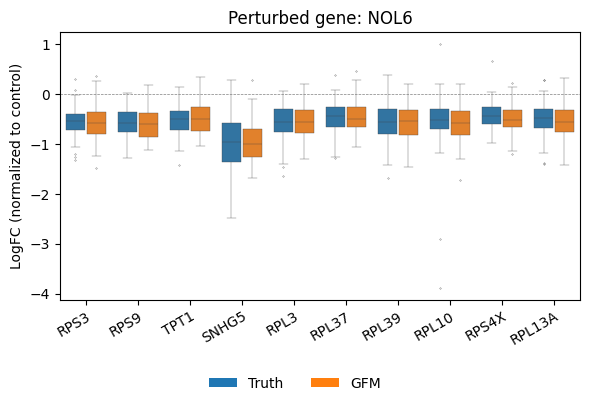

In [5]:
model_name_list=['Truth', 'GFM']

plot_delta_expression_boxplot_model(
    adata,
    condition,
    model_name_list=model_name_list,
    top_n=10,
    figsize=(6, 4)
)